
# 1. Members feature engineering

## integrated_data 불러오기 및 기준일 설정

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")


In [2]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

### 클래스 비율 확인

In [3]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


### member 관련 feature 엔지니어링

#### 멤버정보가 없는 멤버 관련 피쳐 생성

In [4]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

#### registration_init_time

In [5]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [6]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수


In [7]:

df_all['reg_year'] = reg.dt.year                            # 가입 연도




season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

#### gender

In [8]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

#### bd

In [9]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [10]:
df_all["bd_bin"] = pd.cut( # 피쳐로 사용은 나중에
    df_all['bd_clean'],
    bins=[10, 20, 30, 40, 50, 60, np.inf],  # 60세 이상 전체를 포함하도록 np.inf 활용
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,  # 이상 ~ 미만 설정
)

#### city

In [11]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [12]:
# 1. city 값별 사용자 수 및 비중 확인
city_summary = df_all.groupby('city').agg(
    cnt=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

city_summary['ratio'] = (city_summary['cnt'] / len(df_all) * 100).round(2)
print(city_summary.sort_values(by='cnt', ascending=False).head(10))

# 2. city가 1 인 유저들이 성별(gender)이나 나이(bd)도 미입력(NaN/0)인 경우가 많은지 교차 확인
print(df_all[df_all['city'] == 1]['gender_status'].value_counts(normalize=True))
print(df_all[df_all['city'] == 1]['bd_isnan'].value_counts(normalize=True)) 
# city가 1인데 성별 미입력 96퍼, 나이 미입력 97퍼

    city    cnt  churn_rate  ratio
0    1.0  45747    0.063982  45.75
11  13.0   9914    0.122655   9.91
3    5.0   7281    0.130889   7.28
2    4.0   4756    0.137931   4.76
13  15.0   4524    0.125553   4.52
20  22.0   4252    0.120179   4.25
4    6.0   2621    0.141167   2.62
12  14.0   2028    0.114892   2.03
10  12.0   1159    0.121657   1.16
7    9.0    992    0.122984   0.99
gender_status
미입력       0.968370
female    0.016416
male      0.015214
Name: proportion, dtype: float64
bd_isnan
1    0.974031
0    0.025969
Name: proportion, dtype: float64


#### member데이터아닌 다른 데이터 피쳐 엔지니어링

In [13]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [14]:
# 교차에 쓸 그룹 컬럼 (그래프용, 모델에는 안 넣음)
df_all['tenure_grp'] = pd.cut(df_all['tenure_date'],
                               bins=[-1, 365, 730, 1825, np.inf],
                               labels=['1년 미만', '1~2년', '2~5년', '5년 이상'])
df_all['age_grp'] = pd.cut(df_all['bd_clean'], bins=[9, 19, 29, 39, 80],
                            labels=['10대', '20대', '30대', '40대+'])

def age_log_diff(df, col):
    has_log = df['has_log'] == 1
    med = df[has_log].groupby('age_grp', observed=True)[col].median()   # 연령대별 중앙값
    diff = df[col] - df['age_grp'].map(med).astype(float)             # 내 값 - 내 연령대 중앙값
    return diff.where(has_log)                                         # 로그 없는 사람은 NaN

df_all['age_activity_diff'] = age_log_diff(df_all, 'activity_days')
df_all['age_secs_diff']     = age_log_diff(df_all, 'total_secs')


In [15]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff'],
      dtype='object')

In [ ]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    'reg_season',
]

numbers = [
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',
    
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'days_to_expire', 'cancel_on_last_date', 'has_transaction',
    
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',
    
    'trans_per_year', 'pay_per_year',
]

all_col = categories + numbers

In [22]:
from sklearn.model_selection import train_test_split

df_all[categories] = df_all[categories].astype('category')

all_col = categories+numbers

feature = df_all[all_col]
target = df_all[targets]

x_train, x_test, y_train, y_test = train_test_split(feature, target, random_state=args.seed,test_size=0.25, stratify=args.target)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((75000, 29), (75000,), (25000, 29), (25000,))

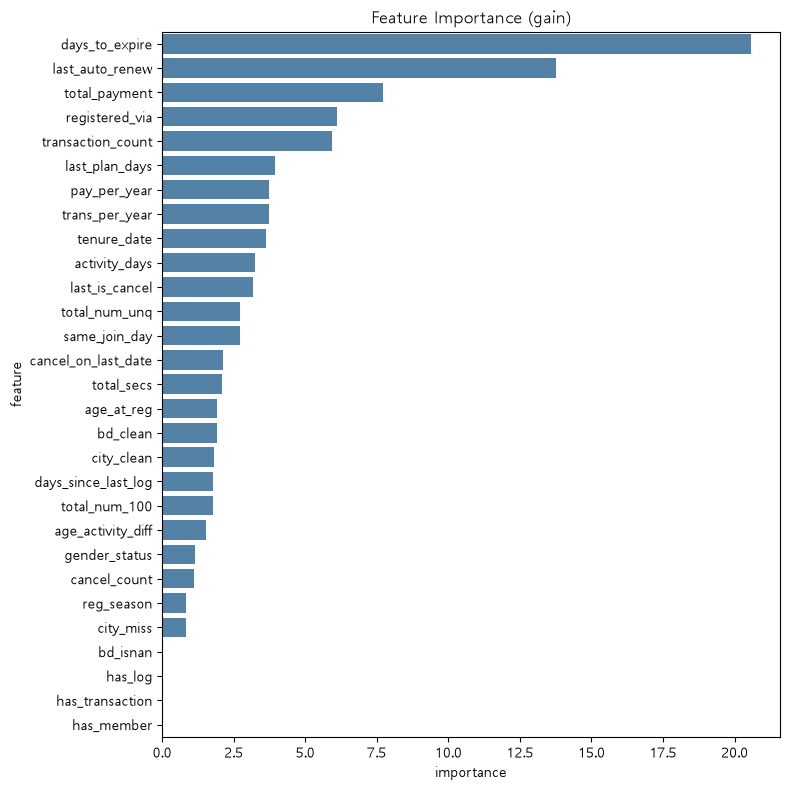

{'conf_mx': array([[0.99310264, 0.00689736],
       [0.44927752, 0.55072248]]), 'report': '              precision    recall  f1-score   support\n\n           0       0.96      0.99      0.97     68287\n           1       0.89      0.55      0.68      6713\n\n    accuracy                           0.95     75000\n   macro avg       0.92      0.77      0.83     75000\nweighted avg       0.95      0.95      0.95     75000\n', 'auc_score': 0.9324548027334034, 'pr_auc': 0.7781242926537806}
{'conf_mx': array([[0.98818206, 0.01181794],
       [0.4950849 , 0.5049151 ]]), 'report': '              precision    recall  f1-score   support\n\n           0       0.95      0.99      0.97     22762\n           1       0.81      0.50      0.62      2238\n\n    accuracy                           0.94     25000\n   macro avg       0.88      0.75      0.80     25000\nweighted avg       0.94      0.94      0.94     25000\n', 'auc_score': 0.9050268017993083, 'pr_auc': 0.6968765040165845}


In [23]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate

#model = ModelType.lgb.create(args.seed)
model = ModelType.cat.create(args.seed, cat_features = categories)

model.fit(x_train, y_train)

score={}
score = evaluate(model, [x_train,y_train], [x_test,y_test])

imp = pd.Series(
    model.feature_importances_,
    index=x_train.columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=imp.values, y=imp.index, color='steelblue')
plt.title('Feature Importance (gain)')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

print(f'{score['train_score']}')
print(f'{score['test_score']}')

datas = get_score(model, x_test,y_test)

conf_mx = datas['conf_mx']


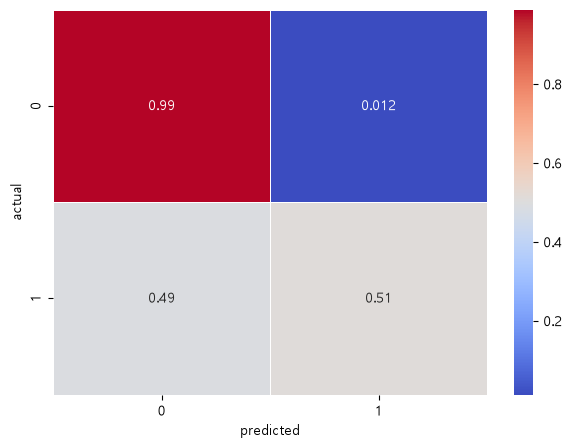

In [19]:

plt.figure(figsize=(7,5))
sns.heatmap(conf_mx, annot=True, cmap='coolwarm',linewidth=0.5)


plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()


(60000, 28) (20000, 28) (20000, 28)
Training until validation scores don't improve for 100 rounds


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Early stopping, best iteration is:
[58]	valid_0's auc: 0.896623	valid_0's binary_logloss: 0.178116
사용된 나무 수: 58


,ROC-AUC,PR-AUC
학습,0.9204,0.7253
검증,0.8966,0.6651
테스트,0.9004,0.6888


기준선: 0.241  (검증 재현율 0.606, 정밀도 0.633)

=== 테스트 · 0.5 기준 (0.500) ===
              precision    recall  f1-score   support

           0      0.950     0.990     0.970     18210
           1      0.817     0.474     0.600      1790

    accuracy                          0.943     20000
   macro avg      0.884     0.732     0.785     20000
weighted avg      0.938     0.943     0.937     20000


=== 테스트 · 조정 기준 (0.241) ===
              precision    recall  f1-score   support

           0      0.963     0.966     0.965     18210
           1      0.643     0.627     0.635      1790

    accuracy                          0.935     20000
   macro avg      0.803     0.797     0.800     20000
weighted avg      0.935     0.935     0.935     20000



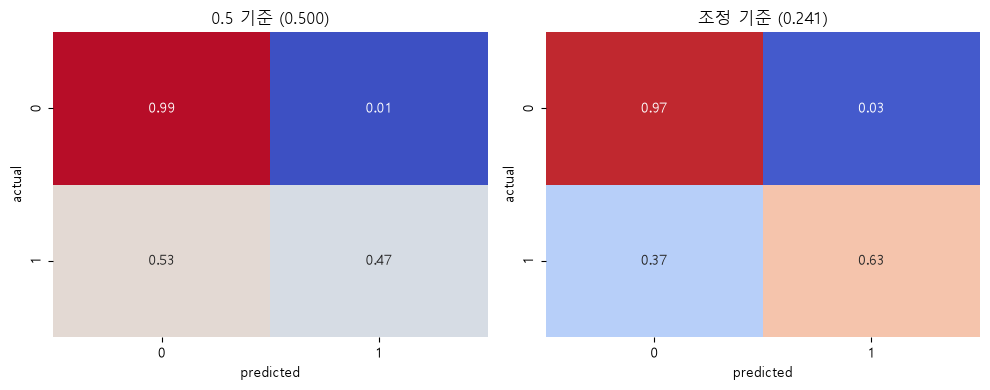

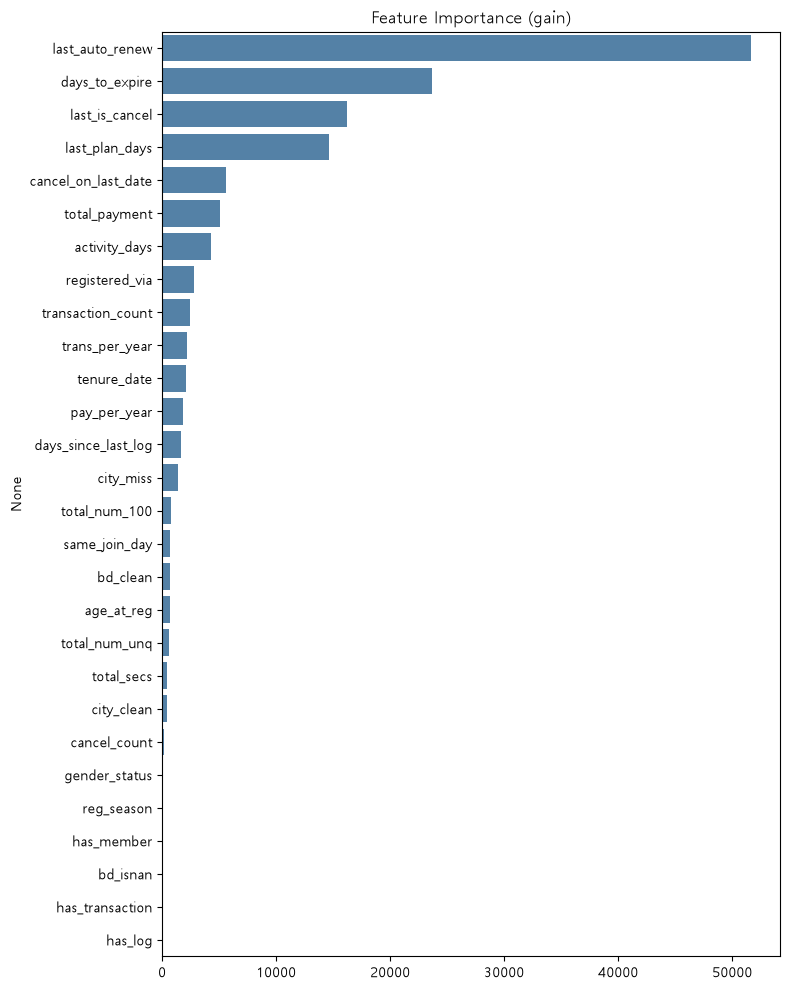

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve)
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

SEED = args.seed

X = df_all[all_col]
y = df_all['is_churn']

# ── 1. 학습 60% / 검증 20% / 테스트 20% ──
x_temp, x_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED)   # 80%의 25% = 전체 20%

print(x_train.shape, x_valid.shape, x_test.shape)


# ── 2. 모델 학습 (검증 점수가 안 오르면 멈춤) ──
model = LGBMClassifier(
    n_estimators=2000,        # 나무 최대 개수. 조기 종료가 적당한 곳에서 멈춰줌
    learning_rate=0.05,       # 나무 하나가 반영되는 비율. 작을수록 천천히 정교하게
    num_leaves=31,            # 나무 하나의 최대 잎 수. 작을수록 단순 (과적합 줄임)
    min_child_samples=50,     # 잎 하나에 최소 인원. 클수록 소수 패턴을 덜 외움
    subsample=0.8,            # 나무마다 행 80%만 사용
    subsample_freq=1,         # subsample을 매 나무마다 적용
    colsample_bytree=0.8,     # 나무마다 컬럼 80%만 사용
    random_state=SEED,
    verbosity=-1,
)
model.fit(
    x_train, y_train,
    eval_set=[(x_valid, y_valid)],       # 이 데이터로 점수를 보며 멈출 시점 판단
    eval_metric='auc',
    callbacks=[early_stopping(100),      # 100번 연속 검증 AUC가 안 오르면 멈춤
               log_evaluation(0)],       # 중간 로그 안 찍음
)
print('사용된 나무 수:', model.best_iteration_)


# ── 3. 확률 예측 ──
p_train = model.predict_proba(x_train)[:, 1]
p_valid = model.predict_proba(x_valid)[:, 1]
p_test  = model.predict_proba(x_test)[:, 1]


# ── 4. 점수 비교표 ──
summary = pd.DataFrame({
    'ROC-AUC': [roc_auc_score(y_train, p_train), roc_auc_score(y_valid, p_valid), roc_auc_score(y_test, p_test)],
    'PR-AUC':  [average_precision_score(y_train, p_train), average_precision_score(y_valid, p_valid), average_precision_score(y_test, p_test)],
}, index=['학습', '검증', '테스트']).round(4)
display(summary)


# ── 5. 기준선 정하기 (검증 데이터로, F1 최대) ──
precision, recall, thresholds = precision_recall_curve(y_valid, p_valid)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best = f1[:-1].argmax()
TH = thresholds[best]
print(f'기준선: {TH:.3f}  (검증 재현율 {recall[best]:.3f}, 정밀도 {precision[best]:.3f})')


# ── 6. 테스트 결과 (0.5 기준 vs 정한 기준선) ──
for name, th in [('0.5 기준', 0.5), ('조정 기준', TH)]:
    pred = (p_test >= th).astype(int)
    print(f'\n=== 테스트 · {name} ({th:.3f}) ===')
    print(classification_report(y_test, pred, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, th) in zip(axes, [('0.5 기준', 0.5), ('조정 기준', TH)]):
    cm = confusion_matrix(y_test, (p_test >= th).astype(int), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1, cbar=False, ax=ax)
    ax.set_title(f'{name} ({th:.3f})')
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.show()


# ── 7. 피처 중요도 (gain) ──
imp = pd.Series(model.booster_.feature_importance(importance_type='gain'),
                index=x_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.barplot(x=imp.values, y=imp.index, color='steelblue')
plt.title('Feature Importance (gain)')
plt.tight_layout(); plt.show()